# MLP trained with article_embeddings for Classification
## Baseline Model for Comparison
https://huggingface.co/spaces/mteb/leaderboard

## 01 Load Data

In [1]:
pip install torch

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split, ParameterGrid
import json
import zipfile
from scipy.sparse import load_npz
import re
import os
import numpy as np
from random import random

import torch
from torch.utils.data import TensorDataset, DataLoader
from torch.optim import Adam
from torch.amp import autocast, GradScaler
from torch.nn import CrossEntropyLoss
import torch.nn.functional as F

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from matplotlib import pyplot as plt
import seaborn as sns

In [3]:
import matplotlib as mpl

# Enable LaTeX-style font
mpl.rcParams['text.usetex'] = True
mpl.rcParams['font.family'] = 'serif'

In [4]:
train_data = pd.read_csv('../02_data/train_test/train_data.csv')
test_data = pd.read_csv('../02_data/train_test/test_data.csv')
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4884 entries, 0 to 4883
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   domain             4884 non-null   object 
 1   url_index          4884 non-null   object 
 2   article            4884 non-null   object 
 3   article_embedding  4884 non-null   object 
 4   virality           4884 non-null   float64
 5   avalanches         4884 non-null   float64
 6   messages           4884 non-null   float64
 7   chats              4884 non-null   float64
 8   pc1                4884 non-null   float64
 9   domain_id          4884 non-null   int64  
dtypes: float64(5), int64(1), object(4)
memory usage: 381.7+ KB


In [5]:
train_data.describe()

,virality,avalanches,messages,chats,pc1,domain_id
count,4884.000000,4884.000000,4884.000000,4884.000000,4884.000000,4884.000000
mean,0.850848,4.698219,10.212041,2.777283,0.593915,3071.599304
std,0.137623,27.906756,107.471890,7.246180,0.201055,1753.755749
min,0.031096,1.000000,1.000000,1.000000,0.000000,0.000000
25%,0.805520,1.333333,1.500000,1.163636,0.491487,1553.750000
50%,0.879083,2.000000,2.454545,1.569499,0.628494,3091.500000
75%,0.939790,3.176311,4.111742,2.264337,0.723936,4588.500000
max,1.000000,1560.000000,5436.625000,196.666667,1.000000,6105.000000


In [6]:
print(train_data['article'].head())

0    ['Come curare i danni da vaccino. Con Giuseppe...
1    ['First Nations use drone-seeding trial projec...
2    ['BREAKING: FBI Raids Homes of 35 Trump Suppor...
3    ['Technology sparks dramatic rise in scams rep...
4    ['UC San Diego unveils new technology to treat...
Name: article, dtype: object


## 02 Preprocessing

In [7]:
train_data['label'] = pd.cut(train_data['pc1'], bins=[-float('inf'), 0.33, 0.66, float('inf')], labels=[0, 1, 2]).astype(int)
test_data['label'] = pd.cut(test_data['pc1'], bins=[-float('inf'), 0.33, 0.66, float('inf')], labels=[0, 1, 2]).astype(int)

train_data["label"].value_counts(normalize=True) * 100  # Percentage of each class

label
1    43.509419
2    41.748567
0    14.742015
Name: proportion, dtype: float64

In [8]:
# Get percentage distributions
train_dist = train_data["label"].value_counts(normalize=True).sort_index() * 100
test_dist = test_data["label"].value_counts(normalize=True).sort_index() * 100

# Combine into a DataFrame
label_dist = pd.DataFrame({
    "Class": train_dist.index,
    "Train (%)": train_dist.values,
    "Test (%)": test_dist.values
})

latex_table = label_dist.to_latex(index=False, float_format="%.2f")
print(latex_table)

\begin{tabular}{rrr}
\toprule
Class & Train (%) & Test (%) \\
\midrule
0 & 14.74 & 13.99 \\
1 & 43.51 & 44.93 \\
2 & 41.75 & 41.08 \\
\bottomrule
\end{tabular}



In [9]:
def preprocess_embedding(emb):
    # If it's already a numpy array, return as is
    if isinstance(emb, np.ndarray):
        return emb

    # If it's a list or other iterable, convert it to a numpy array
    if isinstance(emb, (list, tuple)):
        return np.array(emb, dtype=np.float32)

    # If it's a string, clean and parse
    if isinstance(emb, str):
        try:
            # Fix missing commas using regex
            emb = re.sub(r'(?<=\d)\s+(?=\d|\-)', ',', emb)
            # Ensure it is wrapped in brackets
            if not emb.startswith("["):
                emb = "[" + emb
            if not emb.endswith("]"):
                emb = emb + "]"
            # Evaluate the cleaned string and convert to numpy array
            parsed_emb = eval(emb)  # Using eval since we sanitize the string
            return np.array(parsed_emb, dtype=np.float32)
        except Exception as e:
            raise ValueError(f"Failed to process embedding: {emb}. Error: {e}")

    # If none of the above, raise an error
    raise ValueError(f"Unsupported embedding format: {type(emb)}")


In [10]:
# train_data['article_embedding'] = train_data['article_embedding'].apply(preprocess_embedding)
# test_data['article_embedding'] = test_data['article_embedding'].apply(preprocess_embedding)

In [11]:
def fix_and_parse_embedding(embedding_str):
    # Remove brackets and extra spaces
    clean_str = embedding_str.strip().replace('\n', ' ')
    clean_str = re.sub(r'\s+', ' ', clean_str)
    clean_str = clean_str.strip('[]')
    # Split by space and convert to float
    return [float(x) for x in clean_str.split()]

# Apply fix to train and test
train_embeddings = train_data['article_embedding'].apply(fix_and_parse_embedding).tolist()
test_embeddings = test_data['article_embedding'].apply(fix_and_parse_embedding).tolist()

In [12]:
# Convert to numpy arrays
X_train = np.array(train_embeddings, dtype=np.float32)
X_test = np.array(test_embeddings, dtype=np.float32)

# Create labels based on pc1
y_train = pd.cut(train_data['pc1'], bins=[-float('inf'), 0.33, 0.66, float('inf')], labels=[0, 1, 2]).astype(int).values
y_test = pd.cut(test_data['pc1'], bins=[-float('inf'), 0.33, 0.66, float('inf')], labels=[0, 1, 2]).astype(int).values


In [13]:
# Split training into training and validation
X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

# Convert to tensors
X_train_tensor = torch.tensor(X_train_split, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_split, dtype=torch.long)
X_val_tensor = torch.tensor(X_val_split, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val_split, dtype=torch.long)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

## 03 Model

In [14]:
import torch.nn as nn

class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, output_dim=3, dropout=0.3):
        super(MLP, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, output_dim)
        )

    def forward(self, x):
        return self.model(x)


In [15]:
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, output_dim=3, dropout=0.3):
        super(MLP, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim)
        )

    def forward(self, x):
        return self.model(x)

In [16]:
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, output_dim=3, dropout=0.5):
        super(MLP, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, output_dim)
        )

    def forward(self, x):
        x = self.model(x)
        return F.log_softmax(x, dim=1)

## 04 Model Training

In [17]:
# Check if GPU is available
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print(device)

cuda


In [18]:
# Create data loaders
train_loader = DataLoader(TensorDataset(torch.tensor(X_train), torch.tensor(y_train)), batch_size=32, shuffle=True)
test_loader = DataLoader(TensorDataset(torch.tensor(X_test), torch.tensor(y_test)), batch_size=32)

In [19]:
# Model setup
model = MLP(input_dim=X_train.shape[1]).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=0.005, weight_decay=0.001)

# Training loop
for epoch in range(100):
    model.train()
    total_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")


Epoch 1, Loss: 147.6374
Epoch 2, Loss: 140.0363
Epoch 3, Loss: 138.7487
Epoch 4, Loss: 137.3513
Epoch 5, Loss: 136.6613
Epoch 6, Loss: 136.5003
Epoch 7, Loss: 136.0068
Epoch 8, Loss: 135.1819
Epoch 9, Loss: 135.2834
Epoch 10, Loss: 134.8786
Epoch 11, Loss: 134.6960
Epoch 12, Loss: 134.1489
Epoch 13, Loss: 135.2296
Epoch 14, Loss: 133.6195
Epoch 15, Loss: 132.7806
Epoch 16, Loss: 134.5312
Epoch 17, Loss: 132.4681
Epoch 18, Loss: 134.2973
Epoch 19, Loss: 133.3360
Epoch 20, Loss: 133.9737
Epoch 21, Loss: 133.2326
Epoch 22, Loss: 133.7693
Epoch 23, Loss: 132.4055
Epoch 24, Loss: 132.1043
Epoch 25, Loss: 133.0189
Epoch 26, Loss: 132.2505
Epoch 27, Loss: 132.6173
Epoch 28, Loss: 133.5937
Epoch 29, Loss: 131.4654
Epoch 30, Loss: 133.0826
Epoch 31, Loss: 131.3693
Epoch 32, Loss: 131.7682
Epoch 33, Loss: 132.4943
Epoch 34, Loss: 131.5962
Epoch 35, Loss: 132.0282
Epoch 36, Loss: 132.3868
Epoch 37, Loss: 132.7589
Epoch 38, Loss: 130.9282
Epoch 39, Loss: 132.9567
Epoch 40, Loss: 131.5372
Epoch 41,

## 05 Hyperparameter Tuning

In [20]:
input_dim = X_train.shape[1]

# Define param grid
param_grid = {
    "hidden_size": [32, 64, 128],
    "dropout": [0, 0.3, 0.5],
    "learning_rate": [0.01, 0.005, 0.001],
    "weight_decay": [1e-5, 1e-4, 1e-3]
}

param_grid = list(ParameterGrid(param_grid))

In [21]:
best_val_loss = float("inf")
best_model = None
best_params = None

for params in param_grid:
    print(f"Testing params: {params}")
    
    model = MLP(input_dim=input_dim, hidden_dim=params["hidden_size"], output_dim=3, dropout=params["dropout"]).to(device)
    optimizer = Adam(model.parameters(), lr=params["learning_rate"], weight_decay=params["weight_decay"])
    criterion = nn.CrossEntropyLoss()

    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=32)

    train_losses, val_losses = [], []

    for epoch in range(100):  
        model.train()
        running_loss = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            preds = model(xb)
            loss = criterion(preds, yb)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        train_losses.append(running_loss / len(train_loader))

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                preds = model(xb)
                loss = criterion(preds, yb)
                val_loss += loss.item()
        val_losses.append(val_loss / len(val_loader))

    # Save best
    if val_losses[-1] < best_val_loss:
        best_val_loss = val_losses[-1]
        best_model = model
        best_params = params
        best_train_losses = train_losses
        best_val_losses = val_losses

# Report
print("Best Params:", best_params)
print("Validation Loss:", best_val_loss)


Testing params: {'dropout': 0, 'hidden_size': 32, 'learning_rate': 0.01, 'weight_decay': 1e-05}
Testing params: {'dropout': 0, 'hidden_size': 32, 'learning_rate': 0.01, 'weight_decay': 0.0001}
Testing params: {'dropout': 0, 'hidden_size': 32, 'learning_rate': 0.01, 'weight_decay': 0.001}
Testing params: {'dropout': 0, 'hidden_size': 32, 'learning_rate': 0.005, 'weight_decay': 1e-05}
Testing params: {'dropout': 0, 'hidden_size': 32, 'learning_rate': 0.005, 'weight_decay': 0.0001}
Testing params: {'dropout': 0, 'hidden_size': 32, 'learning_rate': 0.005, 'weight_decay': 0.001}
Testing params: {'dropout': 0, 'hidden_size': 32, 'learning_rate': 0.001, 'weight_decay': 1e-05}
Testing params: {'dropout': 0, 'hidden_size': 32, 'learning_rate': 0.001, 'weight_decay': 0.0001}
Testing params: {'dropout': 0, 'hidden_size': 32, 'learning_rate': 0.001, 'weight_decay': 0.001}
Testing params: {'dropout': 0, 'hidden_size': 64, 'learning_rate': 0.01, 'weight_decay': 1e-05}
Testing params: {'dropout': 0, 

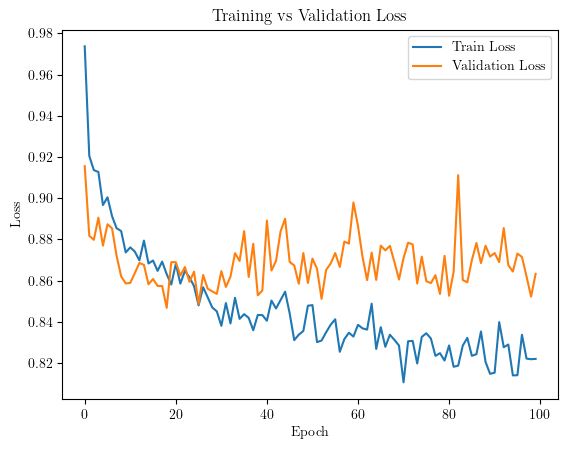

In [22]:
plt.plot(best_train_losses, label='Train Loss')
plt.plot(best_val_losses, label='Validation Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.savefig('../03_plots/train_val_MLP_content.png')
plt.legend()
plt.show()


## 06 Evaluation

In [23]:
#model = BertForSequenceClassification.from_pretrained("./results/final")

In [24]:
from sklearn.metrics import classification_report

model.eval()
y_pred = []
y_true = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        outputs = model(X_batch)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()
        y_pred.extend(preds)
        y_true.extend(y_batch.numpy())

print(classification_report(y_true, y_pred))


              precision    recall  f1-score   support

           0       0.47      0.36      0.41       171
           1       0.53      0.52      0.52       549
           2       0.56      0.62      0.59       502

    accuracy                           0.54      1222
   macro avg       0.52      0.50      0.51      1222
weighted avg       0.53      0.54      0.53      1222



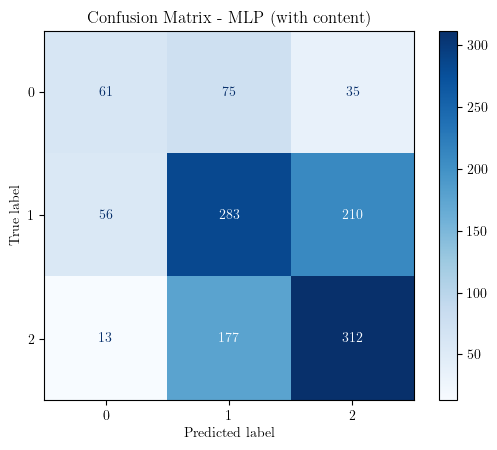

Classification Report:
 {'0': {'precision': 0.46923076923076923, 'recall': 0.3567251461988304, 'f1-score': 0.40531561461794013, 'support': 171.0}, '1': {'precision': 0.5289719626168224, 'recall': 0.5154826958105647, 'f1-score': 0.522140221402214, 'support': 549.0}, '2': {'precision': 0.5601436265709157, 'recall': 0.6215139442231076, 'f1-score': 0.5892351274787536, 'support': 502.0}, 'accuracy': 0.5368248772504092, 'macro avg': {'precision': 0.5194487861395024, 'recall': 0.49790726207750086, 'f1-score': 0.5055636544996359, 'support': 1222.0}, 'weighted avg': {'precision': 0.5334174873598172, 'recall': 0.5368248772504092, 'f1-score': 0.5333551437347116, 'support': 1222.0}}


In [25]:
# Evaluate the model on the test set
# predictions = trainer.predict(val_dataset)
# logits = predictions.predictions
# probabilities = F.softmax(torch.tensor(logits), dim=-1).numpy()
# y_pred = np.argmax(probabilities, axis=1)
# y_true = val_labels

# confusion matrix and classification report
conf_matrix = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(conf_matrix) #, display_labels=["Class 0", "Class 1", "Class 2"]
disp.plot(cmap=plt.cm.Blues)
plt.title(f"Confusion Matrix - MLP (with content)")
plt.savefig('../03_plots/con_matrix_MLP_content.png')
plt.show()

class_report = classification_report(y_true, y_pred, labels=[0,1,2], zero_division=0, output_dict=True)
print("Classification Report:\n", class_report)

In [41]:
report_df = pd.DataFrame(class_report).transpose()
report_df.to_excel('../04_tables/class_report_MLP_content.xlsx')
latex_table = report_df.to_latex()

with open('../04_tables/class_report_MLP_content.tex', 'w') as f:
    f.write(latex_table)

## 05 Testing

In [42]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

accuracy = accuracy_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred, average='weighted')  # or 'macro', 'micro', depending on your need
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')

print("Precision:", precision)
print("Recall:", recall)
print("Accuracy:", accuracy)
print("F1 Score:", f1)

Precision: 0.5368883477808368
Recall: 0.5392798690671031
Accuracy: 0.5392798690671031
F1 Score: 0.5311674944812234
